In [13]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import torch
import pickle

from src.models import GRUModel
from src.train import train_model
from src.evaluate import evaluate_model, plot_predictions, plot_loss

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan cihaz: {device}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Kullanılan cihaz: cuda


In [14]:
# Faz 2'den hazırlanan verileri yükle
# Not: Veri sızıntısını önlemek için scaler ve veriler
# Faz 2'de train/test split sonrası güvenli şekilde kaydedilmiştir.

data = torch.load("../data/processed/amzn_processed.pt", weights_only=True, map_location=device)
scaler = pickle.load(open("../data/processed/scaler.pkl", "rb"))

X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

print(f"📊 Yükleme tamamlandı:")
print(f"   Train: X={X_train.shape}, y={y_train.shape}")
print(f"   Test:  X={X_test.shape}, y={y_test.shape}")

📊 Yükleme tamamlandı:
   Train: X=torch.Size([1996, 20, 1]), y=torch.Size([1996, 1])
   Test:  X=torch.Size([500, 20, 1]), y=torch.Size([500, 1])


In [15]:
# GRUModel oluştur
# input_size=1: sadece Close fiyatı
# hidden_size=50: her GRU katmanında 50 nöron
# num_layers=2: 2 katmanlı GRU
# dropout=0.2: overfitting'i önlemek için %20 nöron dropout

model = GRUModel(input_size=1, hidden_size=50, num_layers=2, dropout=0.2)

param_count = sum(p.numel() for p in model.parameters())
print(f"📐 Parametre sayısı: {param_count:,}")
print(f"   Model cihazı: {device}")

📐 Parametre sayısı: 23,301
   Model cihazı: cuda


In [16]:
# Modeli eğit
# Adam optimizer ile 100 epoch, lr=0.001
# batch_size=64 (mini-batch eğitim)

loss_history, train_time = train_model(
    model, X_train, y_train,
    epochs=100, lr=0.001, device=device
)

print(f"\n📈 Eğitim Sonuçları:")
print(f"   Süre: {train_time:.2f} sn")
print(f"   İlk Loss: {loss_history[0]:.6f}")
print(f"   Son Loss: {loss_history[-1]:.6f}")
print(f"   Loss Azalması: {(1 - loss_history[-1]/loss_history[0])*100:.1f}%")

Epoch [10/100] Loss: 0.002266
Epoch [20/100] Loss: 0.001863
Epoch [30/100] Loss: 0.001530
Epoch [40/100] Loss: 0.001309
Epoch [50/100] Loss: 0.001283
Epoch [60/100] Loss: 0.001168
Epoch [70/100] Loss: 0.001105
Epoch [80/100] Loss: 0.001075
Epoch [90/100] Loss: 0.001126
Epoch [100/100] Loss: 0.001037
✅ Eğitim tamamlandı! Süre: 11.19 sn
   Son Loss: 0.001037

📈 Eğitim Sonuçları:
   Süre: 11.19 sn
   İlk Loss: 0.146056
   Son Loss: 0.001037
   Loss Azalması: 99.3%


📊 Model Değerlendirme:
   MSE : 12.2634
   RMSE: 3.5019 $


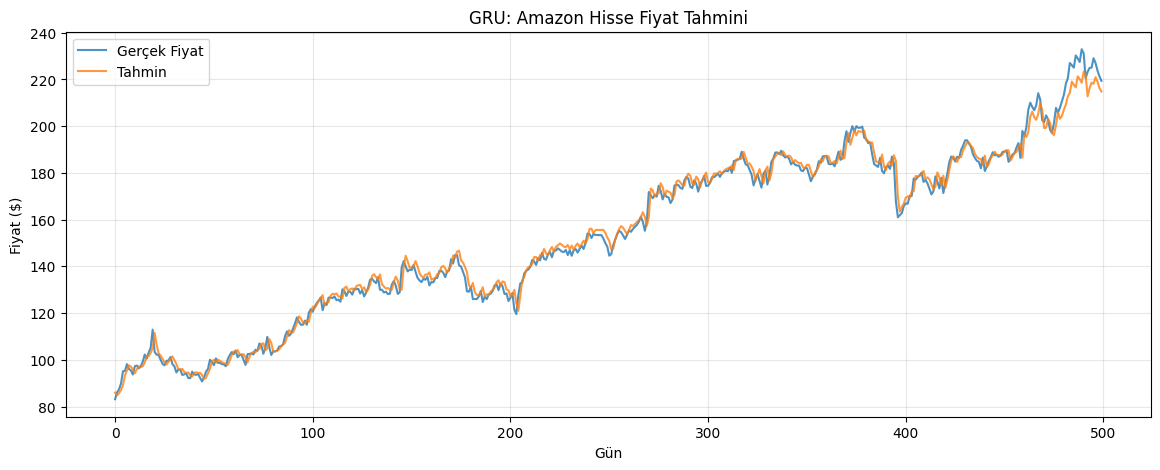

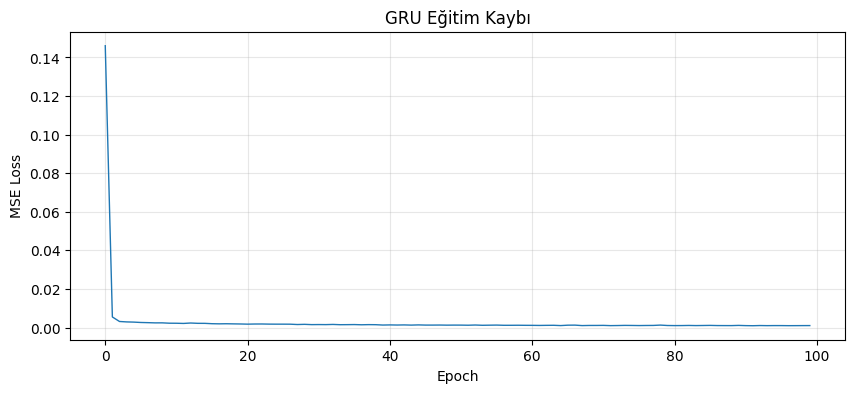

In [17]:
# Modeli test setinde değerlendir
# scaler ile orijinal fiyata geri çevirip görselleştir

preds, actuals, mse, rmse = evaluate_model(
    model, X_test, y_test, scaler=scaler, device=device
)

plot_predictions(actuals, preds,
    title="GRU: Amazon Hisse Fiyat Tahmini",
    save_path="../outputs/figures/gru_predictions.png")

plot_loss(loss_history,
    title="GRU Eğitim Kaybı",
    save_path="../outputs/figures/gru_loss.png")

In [18]:
# Modeli kaydet
# state_dict + hiperparametreler + metrikler birlikte saklanır

torch.save({
    'model_state_dict': model.state_dict(),
    'hidden_size': 50,
    'num_layers': 2,
    'mse': mse,
    'rmse': rmse,
    'train_time': train_time,
}, "../outputs/models/gru_epoch100.pth")

print(f"💾 Model kaydedildi: outputs/models/gru_epoch100.pth")
print(f"   MSE: {mse:.4f}, RMSE: {rmse:.4f}")

💾 Model kaydedildi: outputs/models/gru_epoch100.pth
   MSE: 12.2634, RMSE: 3.5019
